# Бэггинг (Bagging) и случайный лес

В этом ноутбуке разбираются:

1. Что такое бэггинг (Bootstrap AGGregating) и почему он снижает риск
   переобучения — с разбором, **при каких условиях** это действительно
   работает.
2. Модели бэггинга в scikit-learn: `BaggingClassifier`/`BaggingRegressor`,
   `RandomForestClassifier`/`RandomForestRegressor`,
   `ExtraTreesClassifier`/`ExtraTreesRegressor` — параметры, методы, поля.
3. Out-of-bag (OOB) оценка качества — бесплатная замена валидационной
   выборки.
4. Важность признаков (feature importance).
5. Основные ограничения подхода.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import modules.plots as mplts
import modules.style as style

from sklearn.datasets import make_moons, make_regression, load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    BaggingClassifier, BaggingRegressor,
    RandomForestClassifier, RandomForestRegressor,
    ExtraTreesClassifier,
)
from sklearn.inspection import permutation_importance

sns.set_style("whitegrid")
%matplotlib inline

## 1. Что такое бэггинг

**Бэггинг (Bagging, Bootstrap AGGregating)** — идея из двух шагов:

1. **Bootstrap.** Из обучающей выборки размера `n` много раз (по числу
   базовых моделей `M`) случайно выбирается подвыборка того же размера
   `n`, но **с возвращением** — то есть один и тот же объект может
   попасть в подвыборку несколько раз, а другой — не попасть вовсе.
2. **Aggregating.** На каждой такой подвыборке независимо (и, что
   важно, **параллельно** — модели друг от друга не зависят) обучается
   своя копия одной и той же базовой модели. Итоговый прогноз —
   усреднение (для регрессии) или голосование большинством
   (для классификации) прогнозов всех `M` моделей.

Формально: пусть $D = \{(x_i, y_i)\}_{i=1}^{n}$ — обучающая выборка.
Для $m = 1, \dots, M$ строится bootstrap-выборка $D_m$ — $n$ объектов,
выбранных из $D$ случайно и с возвращением, — и на ней обучается
базовая модель $h_m = \mathcal{A}(D_m)$, где $\mathcal{A}$ — один и тот
же алгоритм обучения (например, "построить дерево без ограничения
глубины"). Итоговый прогноз ансамбля:

$$
\hat f_{\text{bag}}(x) = \frac{1}{M}\sum_{m=1}^{M} h_m(x)
\quad\text{(регрессия, усреднение)},
\qquad
\hat f_{\text{bag}}(x) = \operatorname*{mode}_{m=1,\dots,M}\, h_m(x)
\quad\text{(классификация, голосование большинством)}.
$$

Ниже — иллюстрация: как из одного и того же исходного набора объектов
bootstrap-сэмплирование даёт разные (пересекающиеся, но не одинаковые)
подвыборки, в каждой из которых часть объектов повторяется, а часть —
отсутствует ("out-of-bag" для этой подвыборки, к этому вернёмся в
разделе 3).

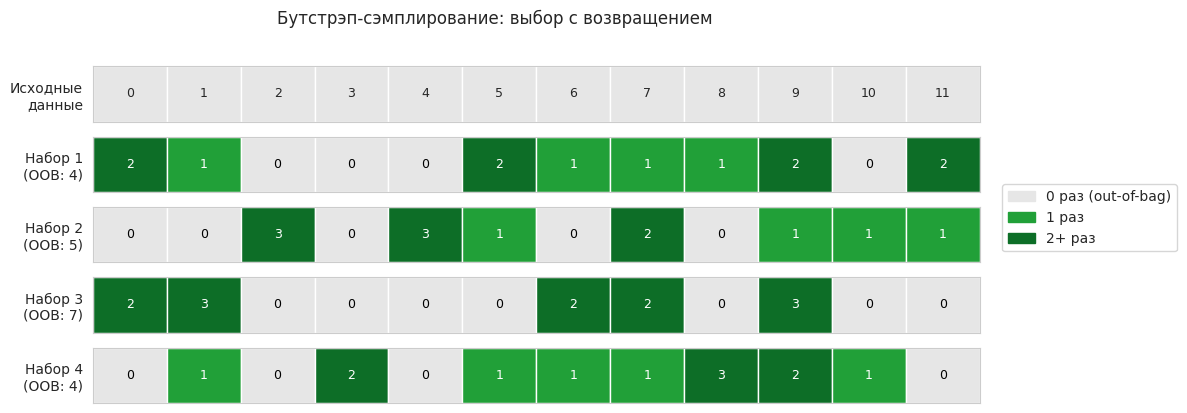

In [2]:
mplts.plot_bootstrap_samples(n_original=12, n_samples=4, random_state=1)
plt.show()

### Почему это снижает риск переобучения — и при каких условиях

Начнём с классического разложения ошибки модели в точке $x$
(bias-variance decomposition) для квадратичной функции потерь:

$$
\mathbb{E}\big[(y - \hat f(x))^2\big]
= \underbrace{\sigma_\varepsilon^2}_{\text{шум в данных}}
+ \underbrace{\big(\mathbb{E}[\hat f(x)] - f^{*}(x)\big)^2}_{\text{Bias}^2}
+ \underbrace{\mathrm{Var}\big[\hat f(x)\big]}_{\text{Variance}},
$$

где $f^{*}(x)$ — истинная (неизвестная) зависимость, а ожидание и
дисперсия берутся по случайности обучающей выборки. Ключевое
наблюдение: поскольку все $D_m$ — bootstrap-выборки из одного и того
же распределения, что и сама обучающая выборка, каждая базовая модель
$h_m$ имеет **то же самое** матожидание прогноза, что и модель,
обученная на всей выборке целиком:
$\mathbb{E}[\hat f_{\text{bag}}(x)] = \mathbb{E}[h_m(x)]$. То есть
**бэггинг не меняет Bias** — он влияет только на слагаемое Variance.
Посмотрим, как именно.

Пусть каждая базовая модель имеет дисперсию прогноза $\sigma^2 =
\mathrm{Var}[h_m(x)]$, а прогнозы любой пары моделей попарно
коррелированы с коэффициентом $\rho = \mathrm{Corr}[h_m(x), h_{m'}(x)]$,
$m \ne m'$ (одинаковым для всех пар в силу симметрии bootstrap-схемы).
Тогда, раскрывая дисперсию суммы через ковариации всех $M^2$ пар
слагаемых:

$$
\mathrm{Var}\!\left(\frac{1}{M}\sum_{m=1}^{M} h_m(x)\right)
= \frac{1}{M^2}\sum_{m=1}^{M}\sum_{m'=1}^{M} \mathrm{Cov}\big(h_m(x), h_{m'}(x)\big)
= \frac{1}{M^2}\Big[\underbrace{M\sigma^2}_{m = m'} + \underbrace{M(M-1)\,\rho\sigma^2}_{m \ne m'}\Big]
= \frac{\sigma^2}{M} + \frac{M-1}{M}\,\rho\sigma^2.
$$

При $M \to \infty$ первое слагаемое исчезает, и дисперсия ансамбля
стремится к $\rho\sigma^2$ — то есть **полностью до нуля дисперсия не
падает никогда**, если модели хоть сколько-то коррелированы ($\rho >
0$), а $\rho = 0$ (полностью независимые модели) на практике
недостижимо, так как все модели видят один и тот же исходный датасет.

Отсюда — два условия, при которых бэггинг действительно эффективно
снижает переобучение (снижает Variance-слагаемое, не трогая Bias):

1. **Базовая модель должна быть низкосмещённой, но высокодисперсной**
   (переобучающейся) — то есть иметь большой $\sigma^2$: классический
   пример — глубокое, "непостриженное" решающее дерево. Если взять,
   наоборот, стабильную низкодисперсную модель (например, линейную
   регрессию без переобучения, у которой $\sigma^2$ и так мало),
   усреднять там особо нечего — бэггинг почти ничего не даст (это мы
   проверим на практике чуть ниже). А если у базовой модели ещё и
   высокий Bias (например, она слишком простая и недообучена), бэггинг
   этот Bias **не исправит** — именно это и есть первое из ограничений
   раздела 5.
2. **Модели должны быть как можно менее скоррелированы друг с другом**
   (низкий $\rho$). Одного bootstrap-сэмплирования для этого часто
   недостаточно: если в данных есть один очень сильный признак, почти
   все деревья всё равно начнут с разбиения по нему и получатся
   похожими (высокий $\rho$). Именно для дополнительного "разъединения"
   деревьев придуман **случайный лес** (раздел 2) — он добавляет к
   bootstrap-сэмплированию ещё и случайный выбор подмножества
   признаков в каждом узле дерева, дополнительно снижая $\rho$.

Проверим первый пункт эмпирически: возьмём одну и ту же точку данных и
посмотрим, насколько сильно "гуляет" предсказание в этой точке у
одиночного дерева и у бэггинга деревьев при пересэмплировании обучающих
данных (имитация того, "что было бы, если бы нам дали чуть другую
обучающую выборку") — то есть оценим $\sigma^2$ напрямую.

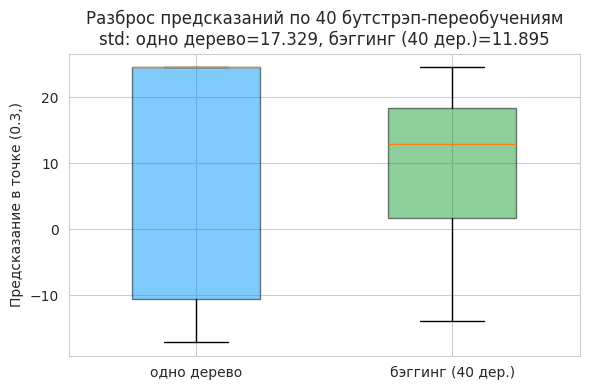

In [3]:
X_reg, y_reg = make_regression(n_samples=120, n_features=1, noise=25, random_state=0)

def build_tree_vs_bagging(random_state):
    single = DecisionTreeRegressor(max_depth=None, random_state=random_state)
    ensemble = BaggingRegressor(DecisionTreeRegressor(max_depth=None),
                                 n_estimators=40, random_state=random_state)
    return single, ensemble

mplts.plot_prediction_variance(build_tree_vs_bagging, X_reg, y_reg, x_query=[0.3],
                                n_runs=40, labels=("одно дерево", "бэггинг (40 дер.)"))
plt.show()

Разброс предсказаний у бэггинга заметно (в несколько раз) меньше,
чем у одиночного дерева — это и есть снижение дисперсии в действии.

А теперь посмотрим на области решений (decision boundary) для
классификации: одиночное дерево против бэггинга против случайного
леса на одних и тех же данных.

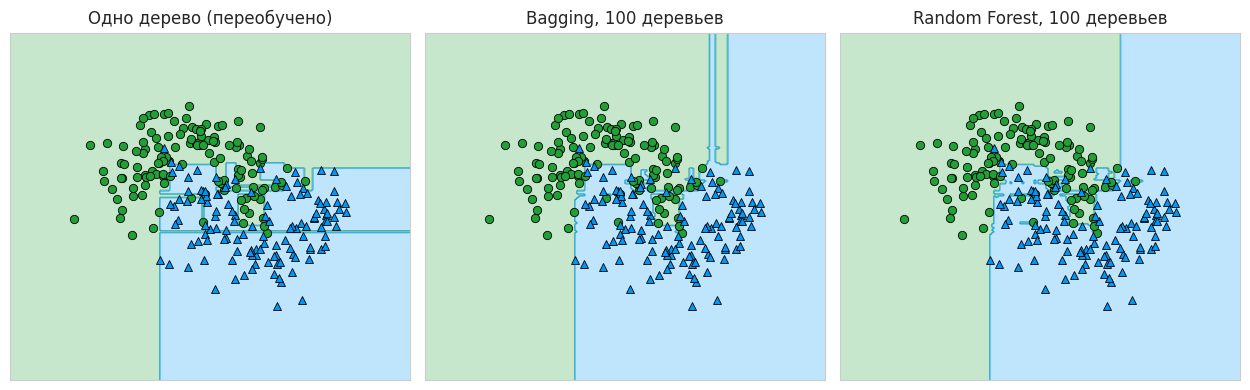

In [4]:
X_moons, y_moons = make_moons(n_samples=250, noise=0.3, random_state=0)

models = {
    "Одно дерево (переобучено)": DecisionTreeClassifier(random_state=0),
    "Bagging, 100 деревьев": BaggingClassifier(DecisionTreeClassifier(), n_estimators=100,
                                                random_state=0),
    "Random Forest, 100 деревьев": RandomForestClassifier(n_estimators=100, random_state=0),
}
mplts.plot_decision_boundaries_grid(models, X_moons, y_moons)
plt.show()

Граница одиночного дерева "рваная" — она подстроилась под шум
конкретной выборки (переобучение). У бэггинга и особенно у случайного
леса граница заметно более гладкая и правдоподобная — это результат
усреднения многих переобученных, но по-разному переобученных деревьев.

Наконец — тот же эффект в виде более абстрактной схемы (не по реальным
данным, а для интуиции): усреднение по многим высокодисперсным моделям
"выглаживает" итоговую кривую в сторону истинной зависимости.

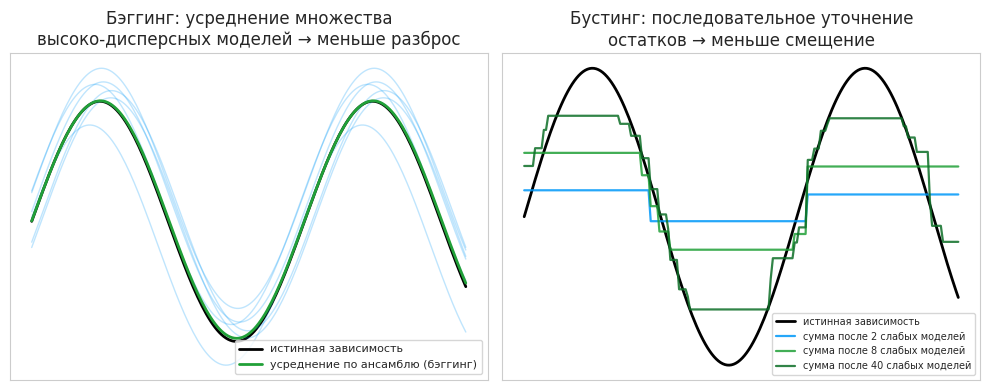

In [5]:
mplts.plot_bias_variance_schematic()
plt.show()

А вот что будет, если применить бэггинг не к переобучающемуся
дереву, а к и так стабильной линейной модели — согласно формуле выше,
выигрыш должен быть минимальным, так как исходная дисперсия $\sigma^2$
одиночной модели и так мала.

In [6]:
scores_single_tree = cross_val_score(DecisionTreeClassifier(random_state=0),
                                      X_moons, y_moons, cv=10)
scores_bagged_tree = cross_val_score(
    BaggingClassifier(DecisionTreeClassifier(), n_estimators=100, random_state=0),
    X_moons, y_moons, cv=10)
scores_single_logreg = cross_val_score(LogisticRegression(), X_moons, y_moons, cv=10)
scores_bagged_logreg = cross_val_score(
    BaggingClassifier(LogisticRegression(), n_estimators=100, random_state=0),
    X_moons, y_moons, cv=10)

print("Дерево:            {:.3f} -> бэггинг деревьев:   {:.3f}  (прирост {:+.3f})".format(
    scores_single_tree.mean(), scores_bagged_tree.mean(),
    scores_bagged_tree.mean() - scores_single_tree.mean()))
print("Лог. регрессия:     {:.3f} -> бэггинг лог.регр.:  {:.3f}  (прирост {:+.3f})".format(
    scores_single_logreg.mean(), scores_bagged_logreg.mean(),
    scores_bagged_logreg.mean() - scores_single_logreg.mean()))

Дерево:            0.844 -> бэггинг деревьев:   0.868  (прирост +0.024)
Лог. регрессия:     0.824 -> бэггинг лог.регр.:  0.824  (прирост +0.000)


Как и предсказывает формула: для дерева (высокая исходная
дисперсия) бэггинг даёт заметный прирост качества, а для логистической
регрессии (низкая исходная дисперсия на этих данных) — почти ничего не
меняет. **Это и есть главное условие, при котором бэггинг работает** —
базовая модель должна быть переобучающейся сама по себе.

## 2. Модели бэггинга в scikit-learn

### 2.1 `BaggingClassifier` / `BaggingRegressor`

Универсальная "обёртка" бэггинга поверх **любой** базовой модели.

**Основные параметры:**
* `estimator` — базовая модель (по умолчанию `DecisionTreeClassifier`/
  `DecisionTreeRegressor`), которую нужно "забэггировать";
* `n_estimators` — число базовых моделей в ансамбле;
* `max_samples` — доля/число объектов в каждой bootstrap-подвыборке
  (по умолчанию — всё, `n` объектов, но с повторами);
* `max_features` — доля/число признаков, случайно отбираемых **для
  каждой базовой модели целиком** (по умолчанию — все признаки): для
  одной базовой модели подмножество признаков выбирается **один раз**,
  до начала её обучения, и дальше вся эта модель (всё дерево целиком,
  если базовая модель — дерево) строится уже только на этом
  фиксированном подмножестве;
* `bootstrap` — сэмплировать ли объекты с возвращением (по умолчанию
  `True`; `False` даёт подвыборки без повторов — по сути "pasting");
* `bootstrap_features` — сэмплировать ли признаки с возвращением;
* `oob_score` — считать ли out-of-bag оценку (раздел 3);
* `n_jobs` — число ядер для параллельного обучения базовых моделей
  (бэггинг **по своей природе легко параллелится** — модели независимы);
* `random_state` — фиксирует случайность (и bootstrap-сэмплирования
  объектов, и, если `bootstrap_features=True`/`max_features<1.0`,
  отбора признаков) для воспроизводимости. Это принципиально важный
  параметр: **бэггинг — стохастический алгоритм**, и без фиксации
  `random_state` (либо при `random_state=None`, как по умолчанию)
  каждый новый вызов `.fit()` на **тех же самых** данных будет
  использовать другой набор bootstrap-выборок — и, соответственно,
  давать другой (хоть обычно и не сильно отличающийся) результат:
  другие `OOB`-оценки, другие обученные деревья, слегка другое
  качество на тесте. Проверим это на практике.

> **Ключевое отличие от `RandomForestClassifier` (раздел 2.2 ниже):**
> в `BaggingClassifier` параметр `max_features` **выбирает подмножество
> признаков один раз на всю базовую модель**, а в `RandomForestClassifier`
> случайное подмножество признаков **выбирается заново в каждом узле
> дерева при поиске разбиения**. Это два разных механизма с одинаковым
> названием параметра `max_features` — их легко перепутать, но именно
> это "переразбиение" признаков в каждом узле (а не только один раз на
> дерево) и есть тот дополнительный источник декорреляции, ради
> которого исторически и был придуман случайный лес поверх обычного
> бэггинга деревьев (см. формулу $\rho\sigma^2$ из раздела 1: чем
> меньше $\rho$, тем ниже итоговая дисперсия).

In [7]:
bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=None),
    n_estimators=100, max_samples=0.8, max_features=0.8,
    bootstrap=True, oob_score=True, n_jobs=-1, random_state=0,
)
bagging_clf.fit(*train_test_split(X_moons, y_moons, random_state=0)[::2])
print("Число базовых моделей в ансамбле:", len(bagging_clf.estimators_))
print("OOB-оценка:", round(bagging_clf.oob_score_, 3))

Число базовых моделей в ансамбле: 100
OOB-оценка: 0.818


In [8]:
# Демонстрация стохастичности бэггинга: один и тот же вызов .fit() на
# тех же данных с одним и тем же random_state даёт ОДИНАКОВЫЙ результат
# (воспроизводимость), а с random_state=None — РАЗНЫЙ при каждом запуске.
X_bag_train, X_bag_test, y_bag_train, y_bag_test = train_test_split(
    X_moons, y_moons, random_state=0)

for rs in [0, 0, None, None, None, None]:
    bc = BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=None),
                            n_estimators=100, max_samples=0.8, max_features=0.8,
                            bootstrap=True, oob_score=True, n_jobs=-1, random_state=rs)
    bc.fit(X_bag_train, y_bag_train)
    print(f"random_state={str(rs):>4s}: OOB-оценка = {bc.oob_score_:.4f}, "
          f"test accuracy = {bc.score(X_bag_test, y_bag_test):.4f}")

random_state=   0: OOB-оценка = 0.8182, test accuracy = 0.8095
random_state=   0: OOB-оценка = 0.8182, test accuracy = 0.8095
random_state=None: OOB-оценка = 0.8449, test accuracy = 0.7778
random_state=None: OOB-оценка = 0.8717, test accuracy = 0.7937
random_state=None: OOB-оценка = 0.8342, test accuracy = 0.8095
random_state=None: OOB-оценка = 0.8449, test accuracy = 0.7302


Как и ожидалось: два запуска с одинаковым `random_state=0` дают
**абсолютно идентичный** результат (одни и те же bootstrap-выборки — та
же OOB-оценка и та же test accuracy с точностью до последнего знака),
а несколько запусков с `random_state=None` — заметно различающиеся OOB-
и test-оценки при каждом новом вызове `.fit()`, хотя обучающие данные
все четыре раза были ровно теми же. Отсюда практический вывод: чтобы
результаты эксперимента с бэггингом были воспроизводимы (и чтобы
корректно сравнивать разные модели/гиперпараметры между собой), нужно
явно фиксировать `random_state`.

### 2.2 `RandomForestClassifier` / `RandomForestRegressor`

Случайный лес — это бэггинг **именно** над решающими деревьями, но с
одним важным дополнением. **Ключевое отличие от обычного
`BaggingClassifier` (раздел 2.1 выше):** там подмножество признаков
(если задан `max_features`) выбирается **один раз на всё дерево**
целиком; в случайном лесе же при поиске лучшего разбиения **в каждом
узле каждого дерева** заново рассматривается **новое** случайное
подмножество признаков размера `max_features` — то есть рандомизация
признаков происходит не один раз на модель, а многократно, на уровне
отдельных узлов. Это и есть тот самый "второй источник рандомизации",
о котором говорилось в разделе 1, — он дополнительно снижает
корреляцию $\rho$ между деревьями (даже если один признак очень
сильный, не в каждом узле он будет доступен для разбиения), а значит,
по формуле выше, сильнее снижает итоговую дисперсию ансамбля по
сравнению с "чистым" бэггингом деревьев, где всё дерево целиком строится
по одному фиксированному подмножеству признаков.

**Основные параметры** (в дополнение к общим для деревьев `max_depth`,
`min_samples_split`, `min_samples_leaf`, `criterion`):
* `n_estimators` — число деревьев;
* `max_features` — размер случайного подмножества признаков,
  пересэмплируемого **на каждом узле** (по умолчанию `"sqrt"` для
  классификации — $\sqrt{p}$ признаков, где $p$ — общее число
  признаков);
* `bootstrap` — использовать ли bootstrap-сэмплирование объектов
  (по умолчанию `True`);
* `oob_score`, `n_jobs`, `random_state` — как у `BaggingClassifier`
  (и стохастичность результата без фиксированного `random_state`
  работает точно так же, как было только что показано);
* `class_weight` — веса классов (для несбалансированной классификации).

**Основные методы и поля после `fit`:**
* `.predict(X)`, `.predict_proba(X)`, `.score(X, y)` — как у любой
  sklearn-модели;
* `.estimators_` — список обученных деревьев (`DecisionTreeClassifier`),
  можно исследовать/визуализировать каждое по отдельности;
* `.feature_importances_` — важность признаков (раздел 4);
* `.oob_score_`, `.oob_decision_function_` — OOB-оценка и
  OOB-предсказанные вероятности (только если `oob_score=True`);
* `.apply(X)` — для каждого объекта возвращает индекс листа, в который
  он попал, в каждом дереве (полезно для построения признаков на
  основе структуры леса).

In [9]:
rf = RandomForestClassifier(n_estimators=200, max_features="sqrt",
                             oob_score=True, n_jobs=-1, random_state=0)
rf.fit(X_moons, y_moons)
print("OOB-оценка случайного леса:", round(rf.oob_score_, 3))
print("Форма oob_decision_function_:", rf.oob_decision_function_.shape)
print("Пример структуры одного дерева из леса: глубина =",
      rf.estimators_[0].get_depth(), ", число листьев =", rf.estimators_[0].get_n_leaves())

OOB-оценка случайного леса: 0.888
Форма oob_decision_function_: (250, 2)
Пример структуры одного дерева из леса: глубина = 10 , число листьев = 31


### 2.3 `ExtraTreesClassifier` / `ExtraTreesRegressor` (Extremely Randomized Trees)

Ещё один шаг в сторону снижения корреляции между деревьями: помимо
случайного подмножества признаков (как в случайном лесе),
Extra-Trees **также случайно выбирает порог разбиения** для каждого
кандидата-признака (вместо того чтобы перебирать и находить оптимальный
порог, как делают обычные деревья). Кроме того, по умолчанию
`bootstrap=False` — деревья строятся на всей обучающей выборке
целиком, а вся рандомизация приходит именно от случайных порогов и
случайного подмножества признаков.

**Плюсы по сравнению со случайным лесом:** ещё ниже корреляция между
деревьями (меньше $\rho$) → иногда ещё лучше снижает дисперсию; быстрее
обучается (не нужно перебирать все пороги — это самая дорогая часть
построения дерева).

**Минусы:** случайные (а не оптимальные) пороги делают отдельные
деревья немного более смещёнными (bias) — в некоторых задачах это может
слегка ухудшить итоговое качество по сравнению со случайным лесом,
плюс результат больше зависит от `random_state`.

In [10]:
et = ExtraTreesClassifier(n_estimators=200, n_jobs=-1, random_state=0)
scores_rf = cross_val_score(rf, X_moons, y_moons, cv=5)
scores_et = cross_val_score(et, X_moons, y_moons, cv=5)
print("Random Forest cv-accuracy: {:.3f} (+-{:.3f})".format(scores_rf.mean(), scores_rf.std()))
print("Extra Trees   cv-accuracy: {:.3f} (+-{:.3f})".format(scores_et.mean(), scores_et.std()))

Random Forest cv-accuracy: 0.876 (+-0.027)
Extra Trees   cv-accuracy: 0.860 (+-0.038)


## 3. Out-of-bag (OOB) оценка

Как было видно на схеме бутстрэпа в разделе 1, каждая bootstrap-
подвыборка не включает часть исходных объектов. Вероятность того, что
конкретный объект вообще не попадёт в одну bootstrap-подвыборку размера
$n$ (при выборе с возвращением из $n$ объектов):

$$
P(\text{объект не попал в } D_m)
= \left(1 - \frac{1}{n}\right)^n
\xrightarrow[n \to \infty]{} \frac{1}{e} \approx 0{,}368.
$$

То есть в среднем $1 - 1/e \approx 63{,}2\%$ уникальных объектов
попадает в подвыборку, а оставшиеся $\approx 36{,}8\%$ для данного
дерева оказываются **out-of-bag (OOB)**. Это значит, что для любого
объекта $x_i$ из обучающей выборки есть деревья $\{h_m : i \notin
D_m\}$, которые его *не видели* при обучении, — и их прогнозы на $x_i$
можно использовать как честную, "как бы тестовую" оценку:

$$
\hat y_{\text{OOB}}(x_i) = \operatorname{aggregate}\big\{h_m(x_i) \;:\; i \notin D_m\big\},
\qquad
\text{OOB-оценка} = \frac{1}{n}\sum_{i=1}^{n} L\big(y_i,\, \hat y_{\text{OOB}}(x_i)\big),
$$

где $\operatorname{aggregate}$ — то же усреднение/голосование, что и
в основном прогнозе ансамбля, а $L$ — нужная метрика качества
(например, доля ошибок для accuracy). Усреднив OOB-прогнозы по всем
деревьям, для которых объект был out-of-bag, и сравнив с истинными
метками, получаем оценку, которая обычно очень близка к оценке на
отдельном тестовом наборе или по кросс-валидации, — но получается
"бесплатно", без дополнительного разбиения данных.

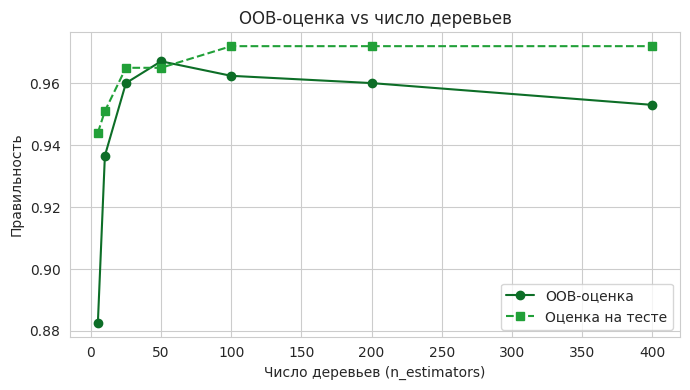

In [11]:
data = load_breast_cancer()
Xc, yc = data.data, data.target
Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, random_state=0)

n_estimators_list = [5, 10, 25, 50, 100, 200, 400]
oob_scores, test_scores = [], []
for n in n_estimators_list:
    rf_n = RandomForestClassifier(n_estimators=n, oob_score=True,
                                   n_jobs=-1, random_state=0).fit(Xc_train, yc_train)
    oob_scores.append(rf_n.oob_score_)
    test_scores.append(rf_n.score(Xc_test, yc_test))

mplts.plot_oob_error_curve(n_estimators_list, oob_scores, test_scores=test_scores)
plt.show()

OOB-кривая и кривая качества на отдельном тесте идут практически
рука об руку — это подтверждает, что OOB-оценку можно использовать как
дешёвую замену валидационной выборке, например, для подбора
`n_estimators` без дополнительной кросс-валидации.

## 4. Важность признаков (feature importance)

У всех ансамблей на основе деревьев после обучения доступен атрибут
`.feature_importances_` — по умолчанию это **Mean Decrease in Impurity
(MDI)**. Для одного дерева важность признака $X_j$ считается как сумма
по всем узлам $t$, где для разбиения использовался именно $X_j$,
взвешенного (по доле объектов $n_t/n$, попавших в узел) уменьшения
"нечистоты" узла:

$$
\mathrm{MDI}(X_j) = \sum_{t:\ \text{split}(t) = X_j} \frac{n_t}{n}\,\Delta i(t),
\qquad
\Delta i(t) = i(t) - \frac{n_{t_L}}{n_t}\, i(t_L) - \frac{n_{t_R}}{n_t}\, i(t_R),
$$

где $i(t)$ — impurity узла $t$ (например, критерий Джини
$i(t) = 1 - \sum_k p_k^2$), а $t_L, t_R$ — его левый и правый
потомки после разбиения. Для ансамбля из $M$ деревьев значения
$\mathrm{MDI}(X_j)$ усредняются по всем деревьям и нормируются в сумму
1 по всем признакам.

**Важная оговорка:** MDI-важность известна тем, что **склонна
завышать важность признаков с большим числом уникальных значений**
(непрерывных или категориальных с высокой кардинальностью) — просто
потому, что для них проще найти хорошее разбиение. Более надёжная (но
дороже вычислительно) альтернатива — **permutation importance**
(`sklearn.inspection.permutation_importance`): она измеряет, насколько
падает качество модели, если значения признака $K$ раз случайно
перемешать между объектами (тем самым "сломав" его связь с целевой
переменной), и не имеет такого смещения:

$$
\mathrm{PI}(X_j) = \mathrm{score}(y, \hat f(X)) - \frac{1}{K}\sum_{k=1}^{K}
\mathrm{score}\big(y,\, \hat f(X^{(j,k)}_{\text{perm}})\big),
$$

где $X^{(j,k)}_{\text{perm}}$ — матрица признаков с $k$-й случайной
перестановкой значений столбца $X_j$ (остальные столбцы не тронуты).

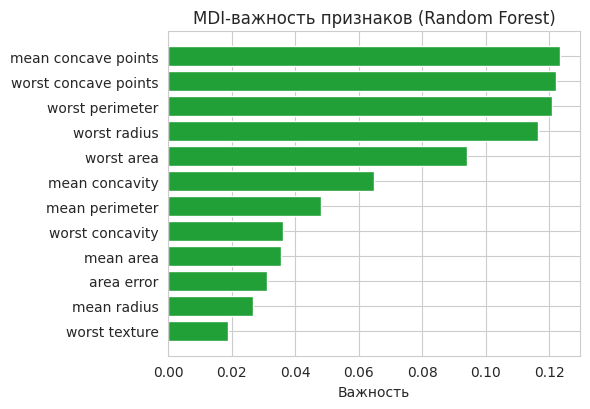

In [12]:
rf_full = RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1)
rf_full.fit(Xc_train, yc_train)

mplts.plot_feature_importances(rf_full.feature_importances_, data.feature_names,
                                title="MDI-важность признаков (Random Forest)", top_n=12)
plt.show()

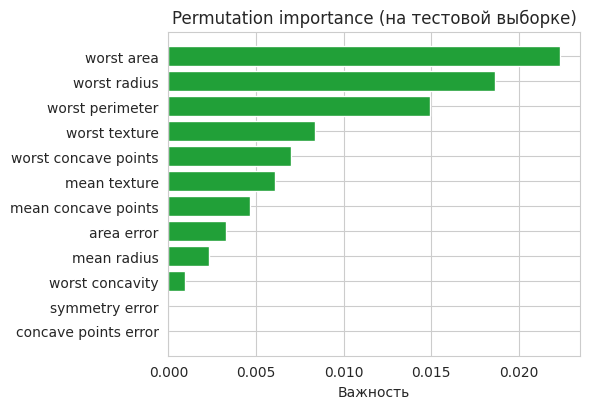

In [13]:
perm = permutation_importance(rf_full, Xc_test, yc_test, n_repeats=15,
                               random_state=0, n_jobs=-1)
mplts.plot_feature_importances(perm.importances_mean, data.feature_names,
                                title="Permutation importance (на тестовой выборке)", top_n=12)
plt.show()

Порядок важности признаков между MDI и permutation importance в
целом похож, но не идентичен — это ожидаемо и является дополнительным
аргументом в пользу того, чтобы не доверять слепо только одному
способу оценки важности, особенно если признаки сильно различаются по
числу уникальных значений.

## 5. Основные ограничения бэггинга

* **Не снижает смещение (bias).** Если базовая модель систематически
  недообучена (высокое смещение — например, слишком неглубокие деревья
  или изначально плохо подходящая модель), усреднение множества таких
  моделей не исправит систематическую ошибку — ансамбль унаследует то
  же смещение, что и отдельная базовая модель. Бэггинг лечит именно
  **дисперсию**, а не bias (в этом его принципиальное отличие от
  бустинга — см. следующий ноутбук).
* **Убывающая отдача (diminishing returns).** Согласно формуле из
  раздела 1, при росте `n_estimators` дисперсия ансамбля стремится не к
  нулю, а к $\rho\sigma^2$ — после определённого числа деревьев
  добавление новых почти не улучшает качество, а только увеличивает
  время обучения/предсказания и память.
* **Эффективность сильно зависит от декоррелированности базовых
  моделей.** Если признаки в данных таковы, что почти все деревья всё
  равно получаются похожими (высокая корреляция $\rho$), выигрыш от
  усреднения ограничен — именно поэтому случайный лес и Extra-Trees
  добавляют дополнительную рандомизацию сверх обычного бэггинга.
* **Хуже интерпретируется**, чем одна модель: вместо одного дерева,
  которое можно нарисовать и прочитать, — сотни деревьев, и понять
  "почему" сделан конкретный прогноз намного сложнее (приходится
  использовать вспомогательные инструменты вроде feature importance,
  partial dependence, SHAP и т.п.).
* **Линейный рост стоимости хранения и инференса** с числом моделей:
  чтобы сделать один прогноз, нужно опросить все `n_estimators` базовых
  моделей — в отличие, например, от одной линейной модели.
* **Не помогает моделям, которые и так стабильны** (низкая исходная
  дисперсия) — как было показано на примере с логистической регрессией
  в разделе 1, для таких моделей бэггинг почти не даёт прироста, но
  всё равно увеличивает вычислительные затраты в `n_estimators` раз.
* Для регрессии на деревьях — **не умеет экстраполировать**: прогноз
  вне диапазона значений, встречавшихся в обучающих данных, будет
  просто "плоским" (равным среднему по ближайшему листу), так как это
  фундаментальное свойство самих деревьев, а не что-то, что бэггинг
  может исправить.

### Сводная таблица

| Модель | Дополнительная рандомизация | Когда использовать |
|---|---|---|
| `BaggingClassifier`/`Regressor` | только bootstrap объектов (+опц. признаков) | нужен бэггинг над произвольной моделью (не только деревом) |
| `RandomForestClassifier`/`Regressor` | bootstrap объектов + случайное подмножество признаков в каждом узле | стандартный выбор "из коробки" для табличных данных |
| `ExtraTreesClassifier`/`Regressor` | случайное подмножество признаков + случайные пороги разбиения | когда нужна максимальная декорреляция деревьев / скорость обучения |
